# CausalML versus EconML: paired Hillstrom RCT comparison

## tl;dr

Across ten implementations on exactly the same holdout:

- **CausalML T-Learner** has the highest Qini (**0.0266**).
- **EconML CausalForestDML** has the lowest calibration RMSE (**0.0257**).
- **CausalML X-Learner** is closest to the RCT ATE (error **0.0028**).
- All **10/10** model-implied ATEs lie inside the RCT 95% confidence interval.

This is a model-validation result, not a production ROI result.

## Context & Methods

The comparison is paired: both libraries receive identical customer rows,
features, treatment, outcome, split, and evaluation functions. S/T/X/DR
families are compared directly. CausalML R-Learner and EconML
CausalForestDML remain in the overall ranking as library-specific additions.

### How an RCT validates CATE models

The experiment directly validates the average effect and provides unbiased,
noisy effect estimates for model-ranked groups. Qini/AUUC test whether higher
predicted effects correspond to greater randomized lift. Calibration RMSE
compares predicted versus observed uplift across ten equal-sized groups.
None of these recovers an individual's unobserved counterfactual.

## Data

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.exceptions import DataConversionWarning

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

RAW_PATH = ROOT / "data" / "raw" / "hillstrom_email_rct.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "hillstrom_mens_email_vs_control.csv"
ARTIFACT_DIR = ROOT / "artifacts"
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

In [2]:
from causal_benchmark.comparison import (
    load_benchmark_artifacts,
    paired_family_comparison,
)
from causal_benchmark.plotting import set_plot_style

set_plot_style()
try:
    metrics, causal_predictions, econ_predictions = load_benchmark_artifacts(
        ARTIFACT_DIR
    )
except FileNotFoundError:
    from causal_benchmark.causalml_runner import run_causalml_rct_benchmark
    from causal_benchmark.econml_runner import run_econml_rct_benchmark
    from causal_benchmark.hillstrom import load_or_create_hillstrom_contrast

    data = load_or_create_hillstrom_contrast(RAW_PATH, PROCESSED_PATH)
    run_causalml_rct_benchmark(data, artifact_dir=ARTIFACT_DIR)
    run_econml_rct_benchmark(data, artifact_dir=ARTIFACT_DIR)
    metrics, causal_predictions, econ_predictions = load_benchmark_artifacts(
        ARTIFACT_DIR
    )

benchmark = metrics.iloc[0]
print(f"Paired randomized holdout rows: {len(causal_predictions):,}")
print(
    f"RCT visit uplift: {benchmark['rct_ate']:.4f} "
    f"(95% CI {benchmark['rct_ci_lower']:.4f} to {benchmark['rct_ci_upper']:.4f})"
)

Paired randomized holdout rows: 12,784
RCT visit uplift: 0.0735 (95% CI 0.0613 to 0.0857)


## Results

### 1. Rank all ten implementations by RCT-based Qini

In [3]:
overall = metrics.sort_values("qini_score", ascending=False).reset_index(drop=True)
display(overall[[
    "library", "model", "qini_score", "auuc_score", "calibration_rmse",
    "ate_abs_error", "ate_within_rct_95ci", "fit_seconds",
]].style.format(precision=4))

,library,model,qini_score,auuc_score,calibration_rmse,ate_abs_error,ate_within_rct_95ci,fit_seconds
0,CausalML,T-Learner,0.0266,0.5251,0.0455,0.0041,True,2.2290
1,EconML,T-Learner,0.0183,0.5168,0.0451,0.0029,True,2.0768
2,EconML,CausalForestDML,0.0177,0.5143,0.0257,0.0045,True,10.6024
3,CausalML,S-Learner,0.0173,0.5150,0.0408,0.0037,True,2.5186
4,EconML,S-Learner,0.0167,0.5148,0.0408,0.0037,True,2.2764
5,EconML,X-Learner,0.0122,0.5073,0.0304,0.0036,True,4.3116
6,CausalML,X-Learner,0.0100,0.5056,0.0304,0.0028,True,4.6217
7,CausalML,R-Learner,0.0073,0.5046,0.0342,0.0037,True,6.5514
8,EconML,DR-Learner,-0.0073,0.4909,0.0333,0.0033,True,7.7090
9,CausalML,DR-Learner,-0.0254,0.4706,0.0403,0.0041,True,5.1619


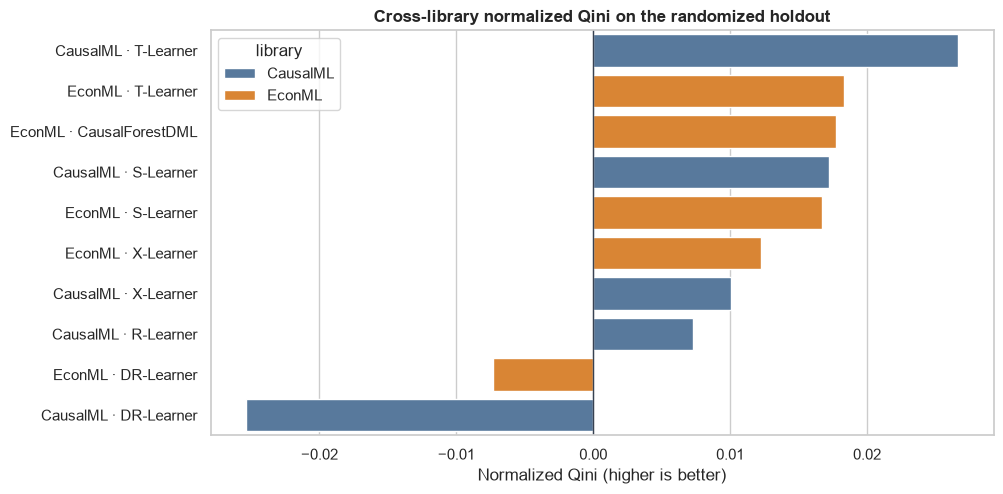

In [4]:
from causal_benchmark.plotting import plot_rct_metric

chart_data = overall.copy()
chart_data["model"] = chart_data["library"] + " · " + chart_data["model"]
plot_rct_metric(
    chart_data,
    "qini_score",
    title="Cross-library normalized Qini on the randomized holdout",
    x_label="Normalized Qini (higher is better)",
)
plt.show()

### 2. Compare shared learner families directly

In [5]:
family_table = paired_family_comparison(metrics, metric="qini_score")
display(family_table.style.format({
    "CausalML": "{:.4f}",
    "EconML": "{:.4f}",
    "absolute_qini_score_gap": "{:.4f}",
}))

library,model,CausalML,EconML,absolute_qini_score_gap,better_library
1,S-Learner,0.0173,0.0167,0.0005,CausalML
3,X-Learner,0.0100,0.0122,0.0022,EconML
2,T-Learner,0.0266,0.0183,0.0083,CausalML
0,DR-Learner,-0.0254,-0.0073,0.0180,EconML


### 3. Check all model-implied average effects against the RCT

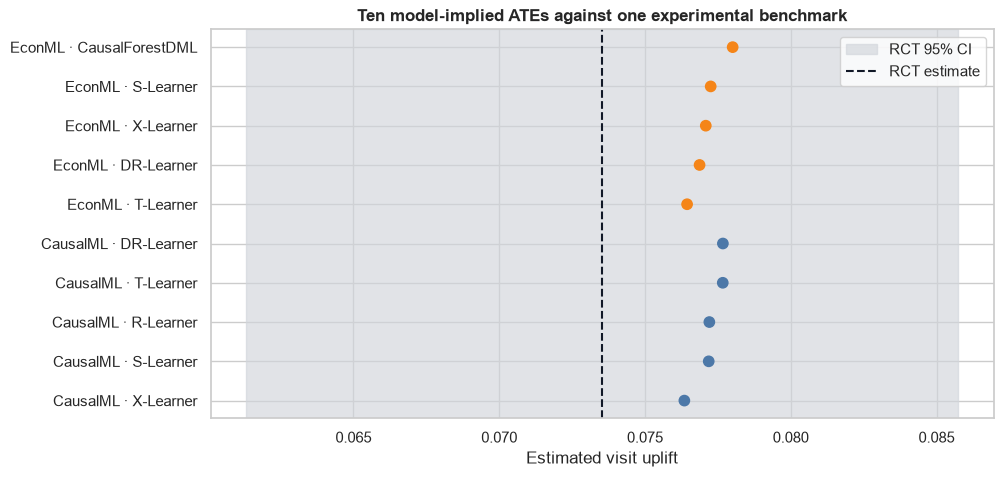

In [6]:
from causal_benchmark.plotting import plot_ate_against_rct

plot_ate_against_rct(
    metrics,
    title="Ten model-implied ATEs against one experimental benchmark",
)
plt.show()

### 4. Compare targeting, calibration, and average-effect leaders

In [7]:
leader_rows = []
for criterion, metric_name, ascending in [
    ("Targeting rank", "qini_score", False),
    ("Group calibration", "calibration_rmse", True),
    ("Average effect", "ate_abs_error", True),
]:
    row = metrics.sort_values(metric_name, ascending=ascending).iloc[0]
    leader_rows.append({
        "criterion": criterion,
        "library": row["library"],
        "model": row["model"],
        "qini_score": row["qini_score"],
        "calibration_rmse": row["calibration_rmse"],
        "ate_abs_error": row["ate_abs_error"],
    })
display(pd.DataFrame(leader_rows).style.format(precision=4))

,criterion,library,model,qini_score,calibration_rmse,ate_abs_error
0,Targeting rank,CausalML,T-Learner,0.0266,0.0455,0.0041
1,Group calibration,EconML,CausalForestDML,0.0177,0.0257,0.0045
2,Average effect,CausalML,X-Learner,0.0100,0.0304,0.0028


### 5. Evaluate deployable policies without fabricating economics

In [8]:
policy = metrics[[
    "library", "model", "policy_email_rate",
    "policy_incremental_visits_per_1000",
    "incremental_visits_per_1000_emailed", "top_30pct_rct_uplift",
]].sort_values("policy_incremental_visits_per_1000", ascending=False)
display(policy.style.format(precision=3))

,library,model,policy_email_rate,policy_incremental_visits_per_1000,incremental_visits_per_1000_emailed,top_30pct_rct_uplift
6,EconML,CausalForestDML,0.999,73.373,73.419,0.080
5,EconML,T-Learner,0.958,73.373,76.553,0.084
8,EconML,X-Learner,0.994,72.747,73.211,0.069
7,EconML,S-Learner,0.977,72.591,74.293,0.085
2,CausalML,X-Learner,0.994,72.434,72.867,0.074
4,CausalML,DR-Learner,0.994,72.121,72.581,0.061
1,CausalML,S-Learner,0.976,71.965,73.753,0.091
0,CausalML,T-Learner,0.964,71.339,74.032,0.095
9,EconML,DR-Learner,0.985,70.713,71.814,0.069
3,CausalML,R-Learner,0.984,70.557,71.701,0.072


## Takeaways

In [9]:
qini_winner = metrics.sort_values("qini_score", ascending=False).iloc[0]
calibration_winner = metrics.sort_values("calibration_rmse").iloc[0]
ate_winner = metrics.sort_values("ate_abs_error").iloc[0]
inside = int(metrics["ate_within_rct_95ci"].sum())
print(
    f"Qini leader: {qini_winner['library']} {qini_winner['model']} "
    f"({qini_winner['qini_score']:.4f})."
)
print(
    f"Calibration leader: {calibration_winner['library']} "
    f"{calibration_winner['model']} "
    f"({calibration_winner['calibration_rmse']:.4f})."
)
print(
    f"Closest ATE: {ate_winner['library']} {ate_winner['model']} "
    f"(error={ate_winner['ate_abs_error']:.4f})."
)
print(f"ATE estimates inside the RCT 95% CI: {inside}/{len(metrics)}.")

Qini leader: CausalML T-Learner (0.0266).
Calibration leader: EconML CausalForestDML (0.0257).
Closest ATE: CausalML X-Learner (error=0.0028).
ATE estimates inside the RCT 95% CI: 10/10.


The cross-library conclusion is deliberately nuanced. Simple T-Learners
rank best here; CausalForestDML calibrates ranked groups best; X-Learner is
closest on the campaign average. Because nearly every predicted effect is
positive, targeting saves few emails. A future business experiment would
need campaign cost and visit/customer value to make an ROI claim.